In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# Collecting data with SAM 2 and Kosmos-2

## Set-up

In [2]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoProcessor, Kosmos2ForConditionalGeneration

# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


# Loading Kosmos-2 and SAM 2

In [3]:

def get_video_segments(predictor, frames_np_lst_selected, boxes):
    inference_state = predictor.init_state(video_path=None, video_frames=frames_np_lst_selected)
    predictor.reset_state(inference_state)

    ann_frame_idx = 0  # the frame index we interact with

    for i in range(len(boxes)):
        ann_obj_id = i + 1
        box = boxes[i]
        _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
            inference_state=inference_state,
            frame_idx=ann_frame_idx,
            obj_id=ann_obj_id,
            box = box
        )

    video_segments = {}  # video_segments contains the per-frame segmentation results
    for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits[i,0] > 0.0).cpu().numpy()
            for i, out_obj_id in enumerate(out_obj_ids)
        }
        
    return video_segments

def process_segments(video_segments, frames_np_lst_selected):
    first_frame_segment = video_segments[0]
    first_frame_mask = np.zeros_like(frames_np_lst_selected[0])[:,:,0]
    for i in range(len(first_frame_segment)):
        mask = first_frame_segment[i+1]
        first_frame_mask = first_frame_mask * (1-mask) + (first_frame_mask * 0 + 1 + i) * mask 

    last_frame_segment = video_segments[1]
    last_frame_mask = np.zeros_like(frames_np_lst_selected[0])[:,:,0]
    for i in range(len(last_frame_segment)):
        mask = last_frame_segment[i+1]
        last_frame_mask = last_frame_mask * (1-mask) + (last_frame_mask * 0 + 1 + i) * mask
    
    image1, image2 = frames_np_lst_selected
    mask1, mask2 = first_frame_mask * 10, last_frame_mask * 10
    return image1, image2, mask1, mask2


def cap_image(image_np):
    height, width, _ = image_np.shape
    image = Image.fromarray(image_np)
    prompt = "<grounding> An image of"
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    generated_ids = model.generate(
        pixel_values=inputs["pixel_values"],
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        image_embeds=None,
        image_embeds_position_mask=inputs["image_embeds_position_mask"],
        use_cache=True,
        max_new_tokens=64,
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    processed_text = processor.post_process_generation(generated_text, cleanup_and_extract=False)
    caption, entities = processor.post_process_generation(generated_text)
    
    boxes_real = []
    
    for ent in entities:
        box = ent[2][0]
        x1 = int(box[0] * width)
        y1 = int(box[1] * height)
        x2 = int(box[2] * width)
        y2 = int(box[3] * height)
        boxes_real.append( np.array([x1,y1,x2,y2], dtype=np.float32))
        
    return caption, entities, boxes_real

# ===  kosmos-2  ===
model = Kosmos2ForConditionalGeneration.from_pretrained("microsoft/kosmos-2-patch14-224")
processor = AutoProcessor.from_pretrained("microsoft/kosmos-2-patch14-224")


# ===  sam-2  ===
from sam2.build_sam import build_sam2_video_predictor
sam2_checkpoint = "./checkpoints/sam2_hiera_large.pt"
model_cfg = "sam2_hiera_l.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


## Select a “video” with two frames

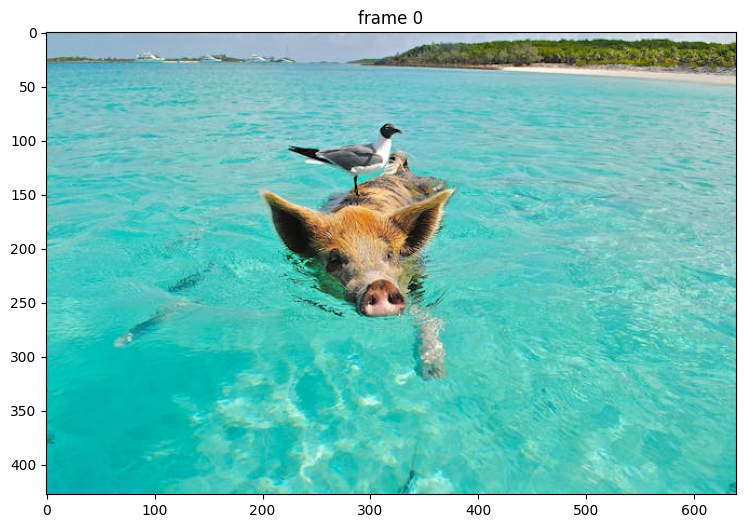

In [4]:
img1_path = '/sensei-fs/users/xic/data/data/Eval/background/03.jpgg'
img2_path = img1_path
frames_np_lst_selected = [ np.array( Image.open(img1_path) ), np.array( Image.open(img2_path) )   ]

# take a look the first video frame
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open( img1_path ))

## kosmos-inference

In [5]:
caption, entities, boxes = cap_image(frames_np_lst_selected[0])
print(caption)
print(entities)
print(boxes)

An image of a pig swimming in the ocean with a bird on its back
[('a pig swimming in the ocean', (12, 39), [(0.296875, 0.265625, 0.609375, 0.765625)]), ('a bird on its back', (45, 63), [(0.359375, 0.203125, 0.515625, 0.328125)])]
[array([189., 113., 389., 327.], dtype=float32), array([229.,  86., 329., 140.], dtype=float32)]


## SAM 2 annotate according to the boxes of kosmos-2

In [6]:

video_segments = get_video_segments(predictor, frames_np_lst_selected, boxes)

image1, image2, mask1, mask2 = process_segments(video_segments, frames_np_lst_selected)

100%|██████████| 2/2 [00:00<00:00, 49.63it/s]


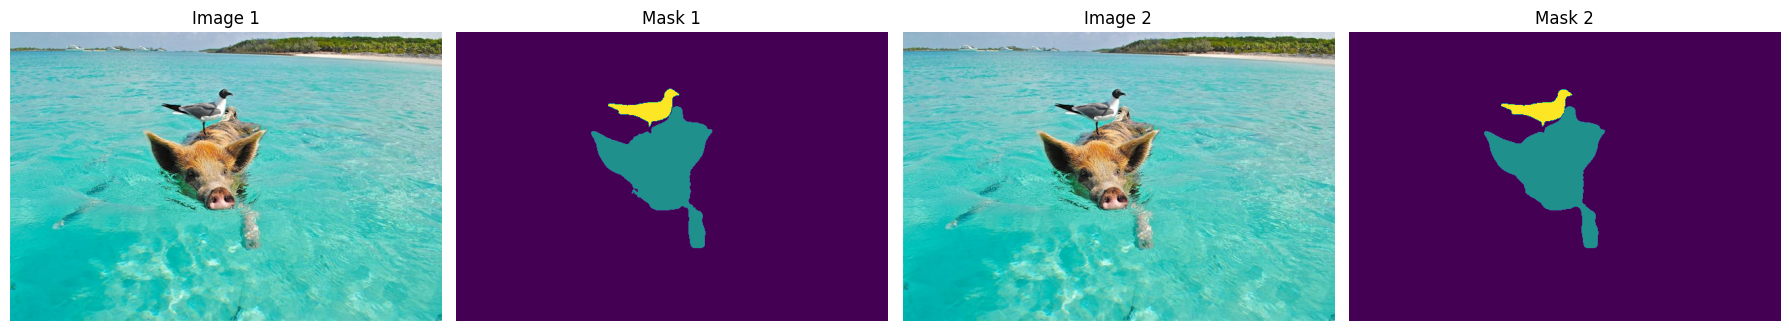

In [7]:
# 创建一个1行4列的子图布局
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# 绘制每个图像
axes[0].imshow(image1)
axes[0].set_title("Image 1")
axes[0].axis('off')

axes[1].imshow(mask1)
axes[1].set_title("Mask 1")
axes[1].axis('off')

axes[2].imshow(image2)
axes[2].set_title("Image 2")
axes[2].axis('off')

axes[3].imshow(mask2)
axes[3].set_title("Mask 2")
axes[3].axis('off')

# 显示图像
plt.tight_layout()
plt.show()